In [1]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
base = os.path.join(os.getcwd(),'..','compiled values')

In [3]:
gpp_grp = os.path.join(base,'gpp graphs')
os.makedirs(gpp_grp,exist_ok=True)

In [4]:
shapeFile = os.path.join(os.getcwd(),'..','shape','States_shapefile.shp')
shape = gpd.read_file(shapeFile)
shape.drop(columns=['FID', 'Program', 'State_Code','Flowing_St', 'FID_1'],inplace=True)
shape.rename(columns={'State_Name':'State'},inplace=True)

In [5]:
lp_sd_ir = pd.read_excel(os.path.join(base,'sdate_irrigated_compiled.xlsx'))
lp_sd_rf = pd.read_excel(os.path.join(base,'sdate_rainfed_compiled.xlsx'))
rs_sd = pd.read_excel(os.path.join(base,'rs_sdate_clean.xlsx'))

In [6]:
lp_hd_ir = pd.read_excel(os.path.join(base,'hdate_irrigated_compiled.xlsx'))
lp_hd_rf = pd.read_excel(os.path.join(base,'hdate_rainfed_compiled.xlsx'))
rs_hd = pd.read_excel(os.path.join(base,'rs_hdate_clean.xlsx'))

In [7]:
rs_hd.drop(columns=['Unnamed: 0'],inplace=True)
rs_hd.rename(columns={'mean':'HD(RS)'},inplace=True)

In [8]:
rs_sd.drop(columns=['Unnamed: 0'],inplace=True)
rs_sd.rename(columns={'mean':'SD(RS)'},inplace=True)

In [9]:
lp_sd_ir['Mean(SO)'] = round(lp_sd_ir['Mean(SO)'])
lp_sd_rf['Mean(SO)'] = round(lp_sd_rf['Mean(SO)'])

In [10]:
lp_hd_ir['Mean(SO)'] = round(lp_hd_ir['Mean(SO)'])
lp_hd_rf['Mean(SO)'] = round(lp_hd_rf['Mean(SO)'])

In [11]:
lp_sd_ir.drop(columns=['Unnamed: 0'],inplace=True)
lp_sd_ir.rename(columns={'Mean(SO)':'SD(IR)','State':'State_Name','Date':'year'},inplace=True)

In [12]:
lp_sd_rf.drop(columns=['Unnamed: 0'],inplace=True)
lp_sd_rf.rename(columns={'Mean(SO)':'SD(RF)','State':'State_Name','Date':'year'},inplace=True)

In [13]:
lp_hd_ir.drop(columns=['Unnamed: 0'],inplace=True)
lp_hd_ir.rename(columns={'Mean(SO)':'HD(IR)','State':'State_Name','Date':'year'},inplace=True)

In [14]:
lp_hd_rf.drop(columns=['Unnamed: 0'],inplace=True)
lp_hd_rf.rename(columns={'Mean(SO)':'HD(RF)','State':'State_Name','Date':'year'},inplace=True)

In [15]:
def gen_index(df):
    if 'date' in df.columns:
        df['year']=df['date'].apply(lambda x:x.year)
        df.drop(columns=['date'],inplace=True)
    df['ival']=df['State_Name']+'-'+df['year'].astype(str)
    df.drop(columns=['State_Name','year'],inplace=True)
    return df

In [16]:
lp_sd_rf = gen_index(lp_sd_rf)
lp_sd_ir = gen_index(lp_sd_ir)
rs_sd = gen_index(rs_sd)

In [17]:
lp_hd_rf = gen_index(lp_hd_rf)
lp_hd_ir = gen_index(lp_hd_ir)
rs_hd = gen_index(rs_hd)

In [18]:
sd_compiled = pd.merge(lp_sd_rf,lp_sd_ir,on='ival')
sd_compiled = pd.merge(sd_compiled,rs_sd,on='ival')

In [19]:
hd_compiled = pd.merge(lp_hd_rf,lp_hd_ir,on='ival')
hd_compiled = pd.merge(hd_compiled,rs_hd,on='ival')

In [20]:
gs=sd_compiled.merge(hd_compiled,on='ival')
gs['year']=gs['ival'].apply(lambda x:int(x.split('-')[1]))
gs['State']=gs['ival'].apply(lambda x:(x.split('-')[0]))
gs = gs.set_index('ival')

In [21]:
gs['Growing period(IR)'] = gs['HD(IR)']-gs['SD(IR)']
gs['Growing period(RF)'] = gs['HD(RF)']-gs['SD(RF)']
gs['Growing period(RS)'] = gs['HD(RS)']-gs['SD(RS)']

In [36]:
gs[gs['Growing period(IR)'] < 0] = np.nan
gs[gs['Growing period(RF)'] < 30] = np.nan

In [37]:
y1 = gs[gs['year']==2015]
y2 = gs[gs['year']==2016]
y3 = gs[gs['year']==2017]
y4 = gs[gs['year']==2018]
y5 = gs[gs['year']==2019]
y1_gdf = shape.merge(y1,on='State',how='left') 
y2_gdf = shape.merge(y2,on='State',how='left') 
y3_gdf = shape.merge(y3,on='State',how='left') 
y4_gdf = shape.merge(y4,on='State',how='left') 
y5_gdf = shape.merge(y5,on='State',how='left') 

In [38]:
gdf_list = [y1_gdf,y2_gdf,y3_gdf,y4_gdf,y5_gdf]
cols = ['Growing period(RF)','Growing period(IR)','Growing period(RS)']

In [39]:
vmin

51.0

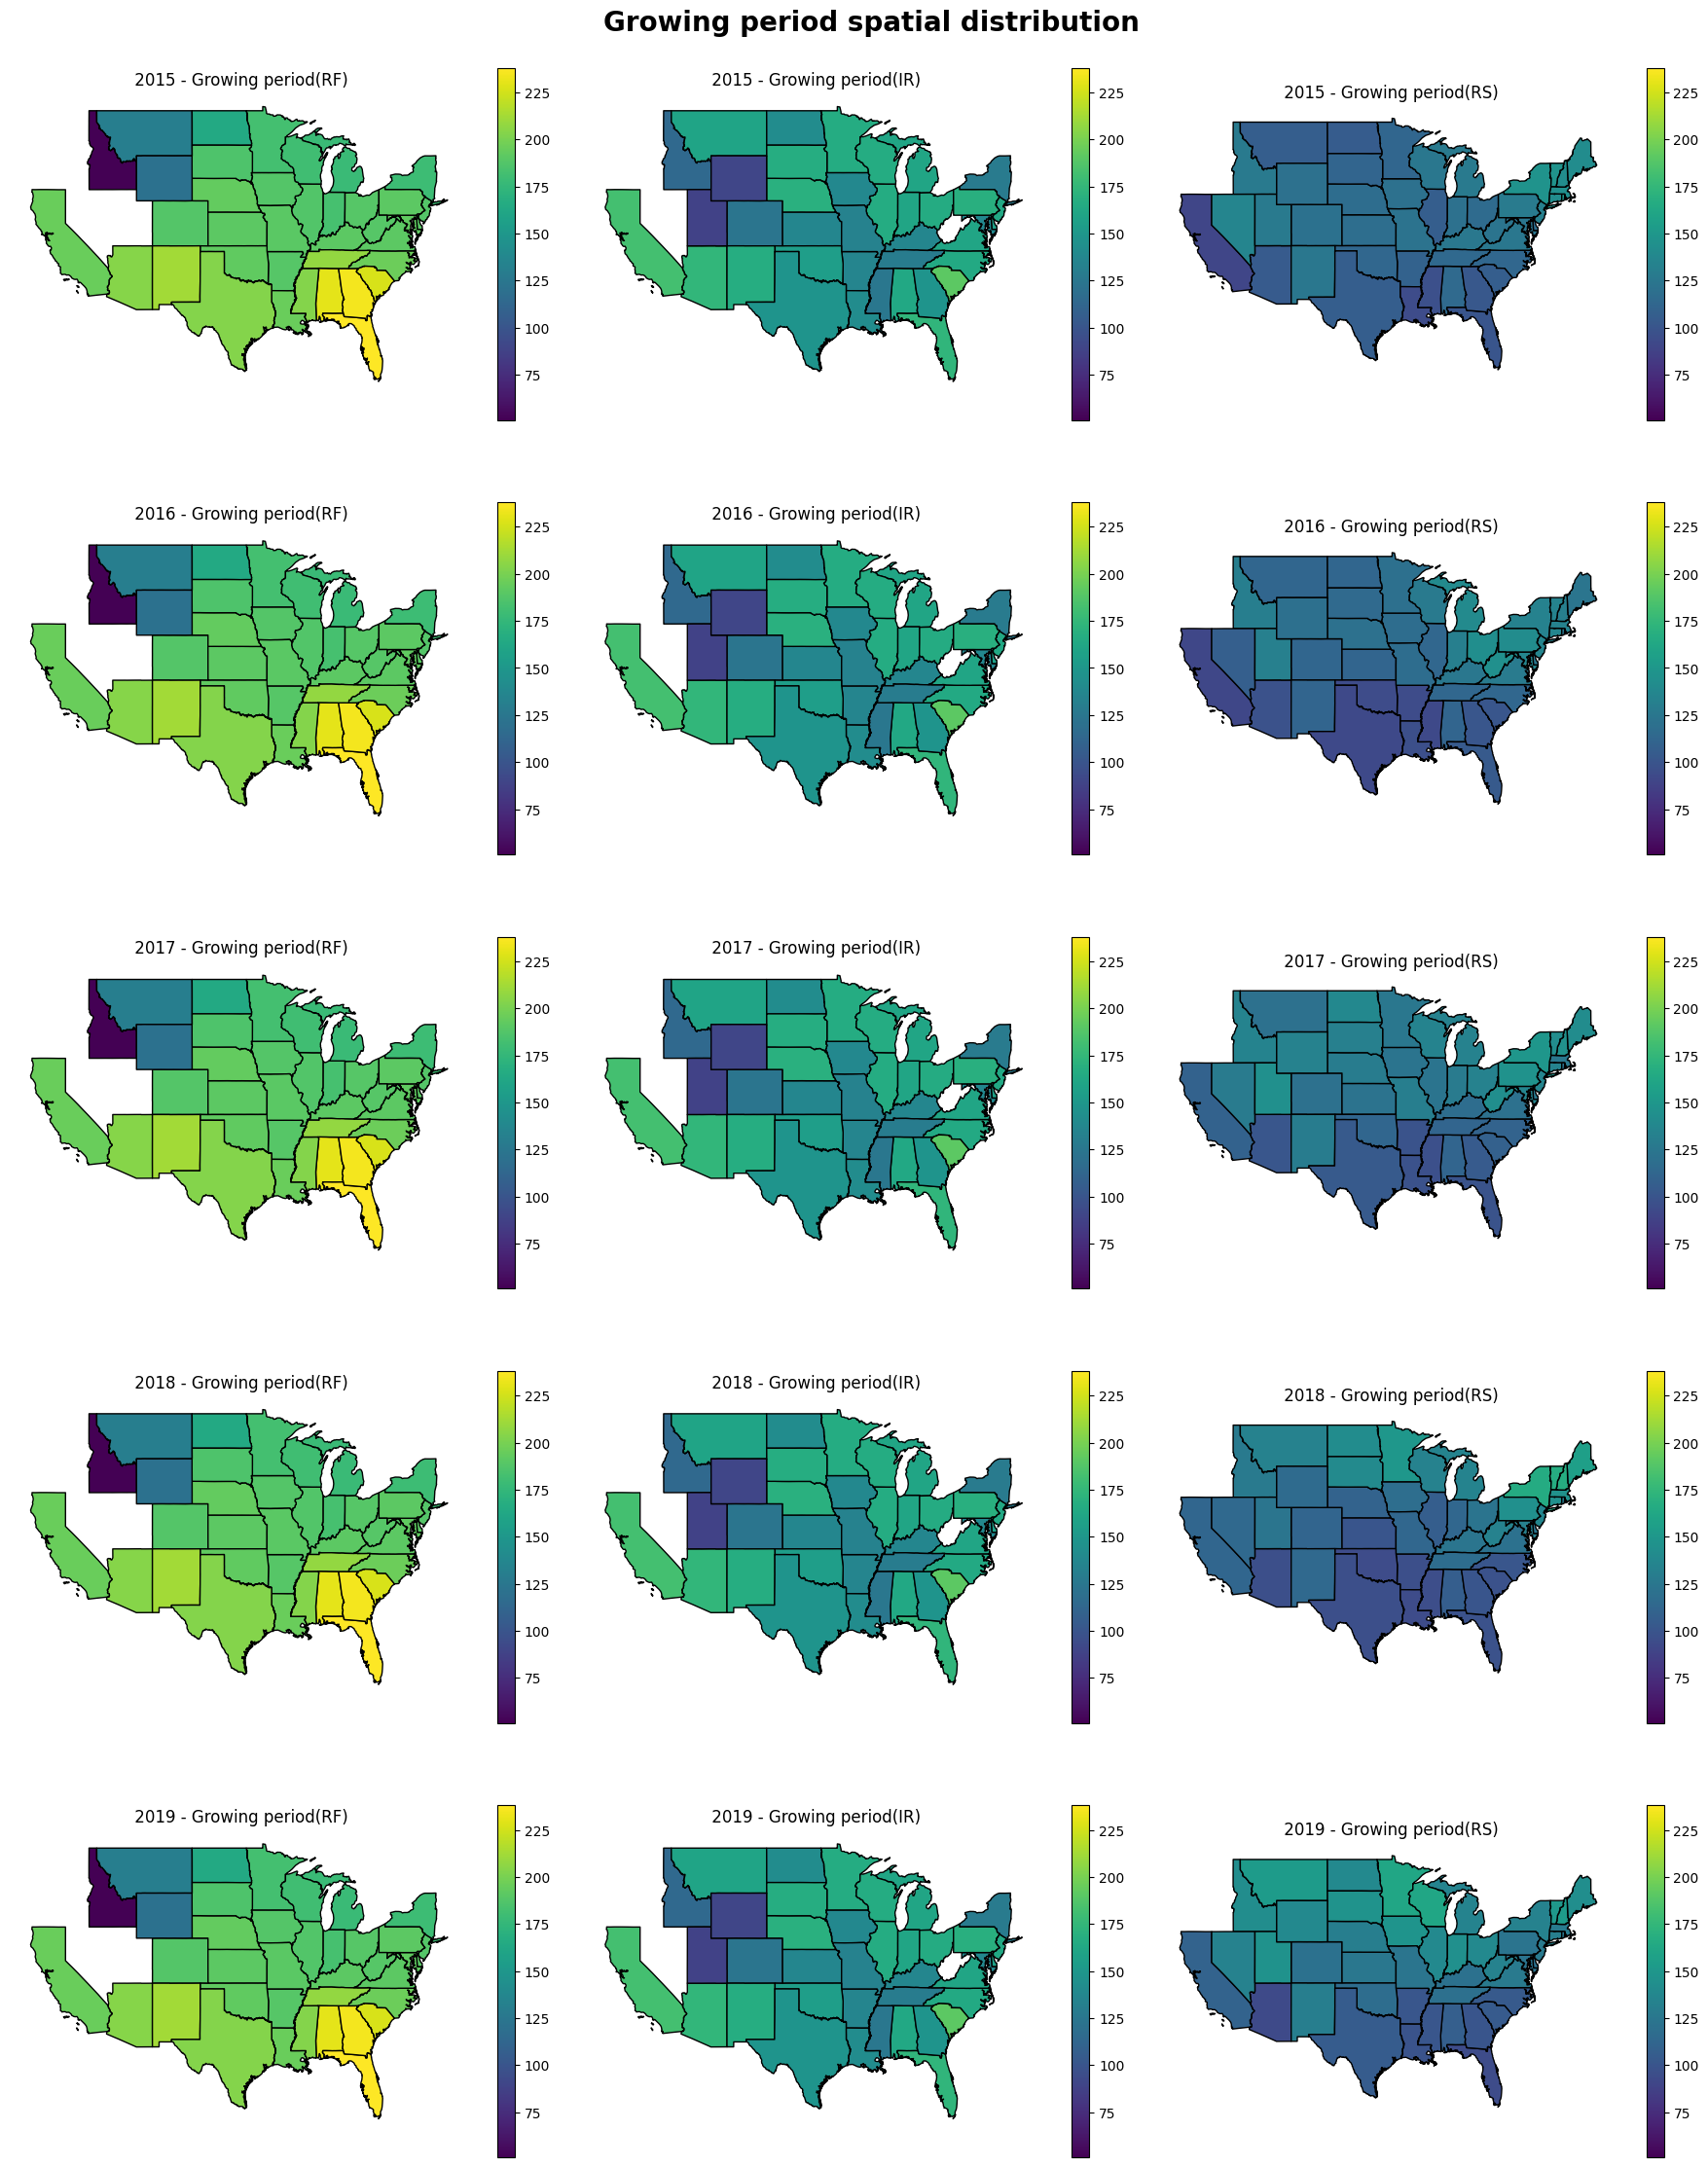

In [41]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(18, 25))
vmin = gs[gs['year']>=2015][cols].min().min()
vmax = gs[gs['year']>=2015][cols].max().max()
for row, gdf in enumerate(gdf_list):
    for col_idx, col_name in enumerate(cols):
        
        ax = axes[row, col_idx]
        
        gdf.plot(
            column=col_name,
            ax=ax,
            cmap='viridis',
            vmax=vmax,
            vmin=vmin,
            legend=True,
            edgecolor='black',
            
            legend_kwds={'shrink': 0.7}
        )
        
        ax.set_title(f" {row+2015} - {col_name}", fontsize=12)
        ax.axis('off')

# Add super title
fig.suptitle(
    "Growing period spatial distribution",
    fontsize=20,
    fontweight='bold',
    y=0.92
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fn = os.path.join(gpp_grp,'Growth period_gt15.png')
plt.savefig(fn, bbox_inches='tight',dpi=300)
plt.show()

In [42]:
y1 = gs[gs['year']==2010]
y2 = gs[gs['year']==2011]
y3 = gs[gs['year']==2012]
y4 = gs[gs['year']==2013]
y5 = gs[gs['year']==2014]
y1_gdf = shape.merge(y1,on='State',how='left') 
y2_gdf = shape.merge(y2,on='State',how='left') 
y3_gdf = shape.merge(y3,on='State',how='left') 
y4_gdf = shape.merge(y4,on='State',how='left') 
y5_gdf = shape.merge(y5,on='State',how='left') 

In [43]:
gdf_list = [y1_gdf,y2_gdf,y3_gdf,y4_gdf,y5_gdf]
cols = ['Growing period(RF)','Growing period(IR)','Growing period(RS)']

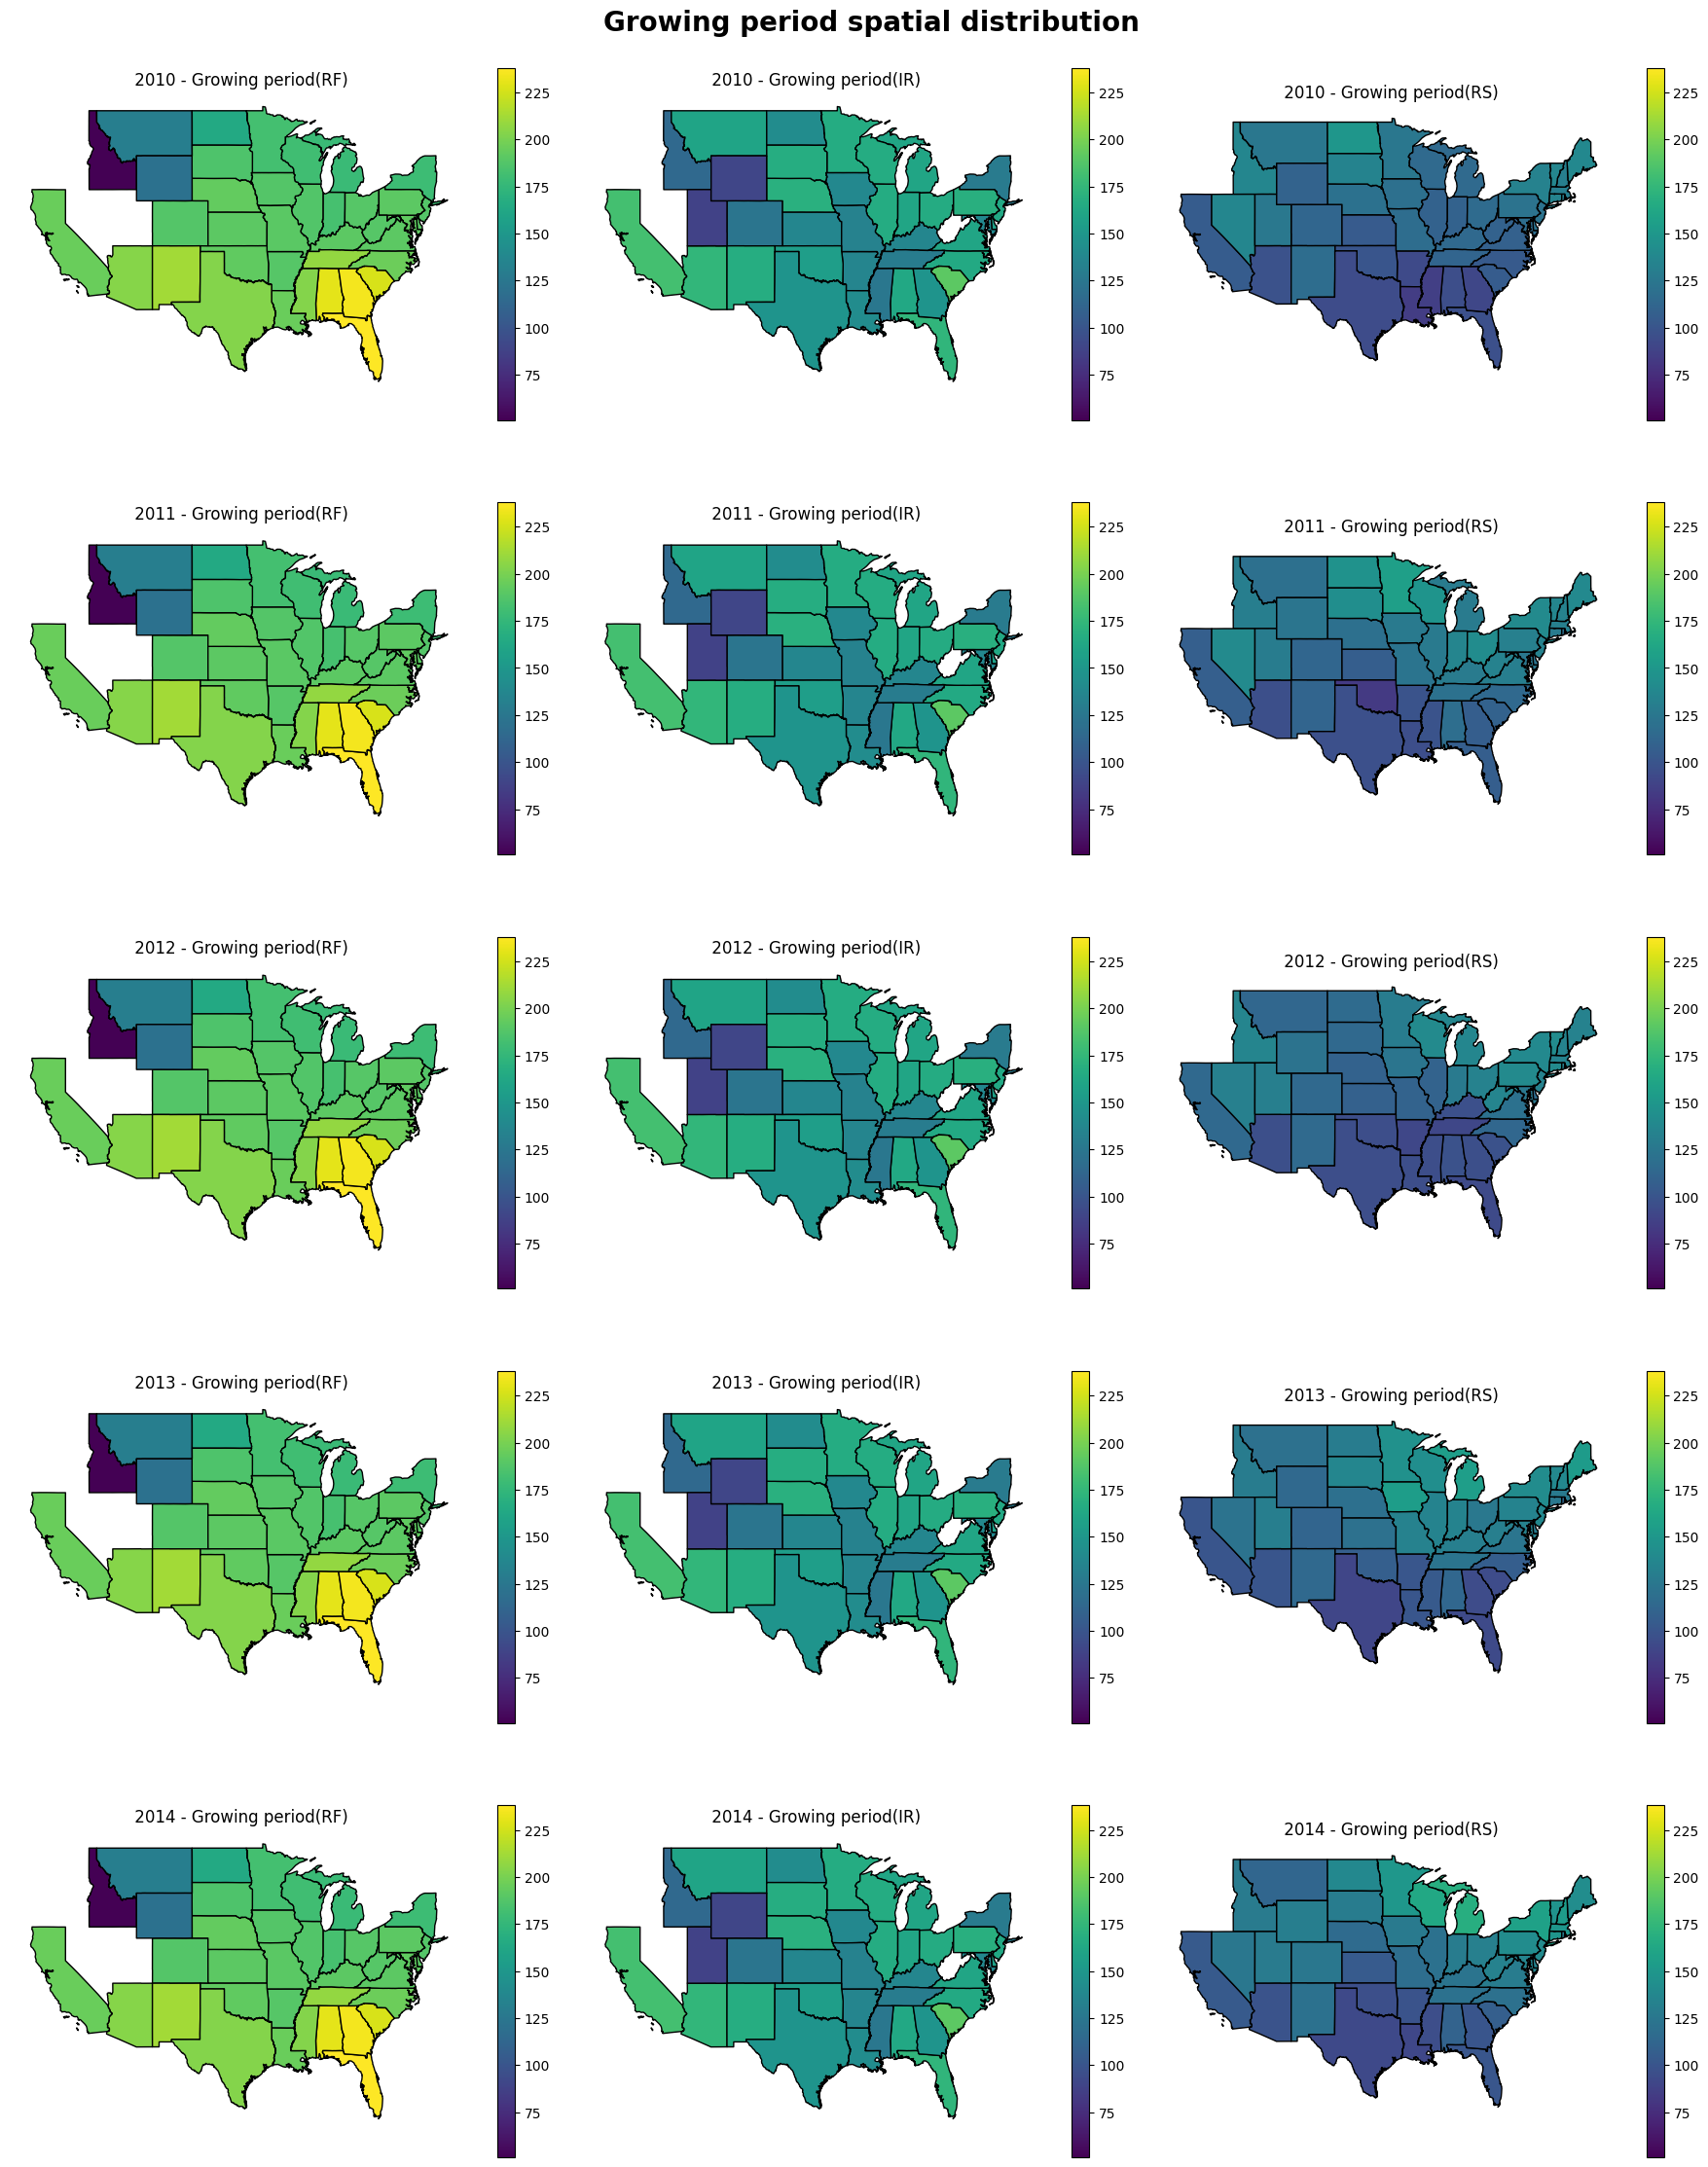

In [45]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(18, 25))
vmin = gs[gs['year']<2015][cols].min().min()
vmax = gs[gs['year']<2015][cols].max().max()
for row, gdf in enumerate(gdf_list):
    for col_idx, col_name in enumerate(cols):
        
        ax = axes[row, col_idx]
        
        gdf.plot(
            column=col_name,
            ax=ax,
            cmap='viridis',
            vmax=vmax,
            vmin=vmin,
            legend=True,
            edgecolor='black',
            
            legend_kwds={'shrink': 0.7}
        )
        
        ax.set_title(f" {row+2010} - {col_name}", fontsize=12)
        ax.axis('off')

# Add super title
fig.suptitle(
    "Growing period spatial distribution",
    fontsize=20,
    fontweight='bold',
    y=0.92
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
fn = os.path.join(gpp_grp,'Growth period_lt15.png')
plt.savefig(fn, bbox_inches='tight',dpi=300)
plt.show()